In [54]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import to_timestamp, to_date, count, avg, dayofweek, month, when, col, lag, weekofyear, year, lit, quarter
from pyspark.sql.window import Window
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [55]:

spark = SparkSession.builder.appName("AccidentForecasting").getOrCreate()

df = spark.read.csv("cleaned_sampled_accident_data.csv/part-00000-1143a236-e999-457e-b27f-edb12dd34ec3-c000.csv", header=True, inferSchema=True)

In [56]:
df.printSchema()

root
 |-- ID: string (nullable = true)
 |-- Source: string (nullable = true)
 |-- Severity: integer (nullable = true)
 |-- Start_Time: timestamp (nullable = true)
 |-- End_Time: timestamp (nullable = true)
 |-- Start_Lat: double (nullable = true)
 |-- Start_Lng: double (nullable = true)
 |-- End_Lat: double (nullable = true)
 |-- End_Lng: double (nullable = true)
 |-- Distance(mi): double (nullable = true)
 |-- Description: string (nullable = true)
 |-- Street: string (nullable = true)
 |-- City: string (nullable = true)
 |-- County: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Zipcode: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Timezone: string (nullable = true)
 |-- Airport_Code: string (nullable = true)
 |-- Weather_Timestamp: timestamp (nullable = true)
 |-- Temperature(F): double (nullable = true)
 |-- Wind_Chill(F): double (nullable = true)
 |-- Humidity(%): double (nullable = true)
 |-- Pressure(in): double (nullable = true)
 |-- V

In [57]:
cols = ["ID", "Start_Time", "City", "State", "Temperature(F)", "Humidity(%)", 
        "Visibility(mi)", "Precipitation(in)", "Weather_Condition"]
df = df.select(*cols)


In [58]:
df = df.withColumn("Start_Time", to_timestamp("Start_Time"))
df = df.withColumn("Date", to_date("Start_Time"))

In [59]:
df.show(5)

+---------+-------------------+--------+-----+--------------+-----------+--------------+-----------------+-------------------+----------+
|       ID|         Start_Time|    City|State|Temperature(F)|Humidity(%)|Visibility(mi)|Precipitation(in)|  Weather_Condition|      Date|
+---------+-------------------+--------+-----+--------------+-----------+--------------+-----------------+-------------------+----------+
|A-3447191|2016-12-06 14:28:06|   Akron|   OH|          39.9|       86.0|           3.0|             0.05|         Light Rain|2016-12-06|
|A-3420085|2016-04-27 03:50:41|Calimesa|   CA|          49.0|       86.0|          10.0|              0.0|      Partly Cloudy|2016-04-27|
|A-3456576|2017-01-05 16:33:16| Chicago|   IL|          12.0|       56.0|          10.0|              0.0|      Mostly Cloudy|2017-01-05|
|A-3458082|2017-01-10 15:48:54|Syracuse|   NY|          28.4|       86.0|           4.0|             0.06|Light Freezing Rain|2017-01-10|
|A-3459593|2017-01-16 06:48:42|  S

In [60]:
daily_counts = (
    df.groupBy("City", "Date")
      .agg(count("ID").alias("Accident_Count"))
)

weather_agg = (
    df.groupBy("City", "Date")
      .agg(
          avg("Temperature(F)").alias("Temp"),
          avg("Humidity(%)").alias("Humidity"),
          avg("Visibility(mi)").alias("Visibility"),
          avg("Precipitation(in)").alias("Precip")
      )
)

data = daily_counts.join(weather_agg, ["City", "Date"], "left")

In [61]:
data.show(5)

+-------------+----------+--------------+----+--------+----------+------+
|         City|      Date|Accident_Count|Temp|Humidity|Visibility|Precip|
+-------------+----------+--------------+----+--------+----------+------+
|    Charlotte|2016-12-06|             1|46.0|    89.0|      10.0|   0.0|
|   Cincinnati|2022-12-14|             1|40.0|    93.0|       1.0|  0.17|
|   Sacramento|2022-04-13|             1|54.0|    44.0|      10.0|   0.0|
|      Madison|2022-03-21|             1|74.0|    18.0|      10.0|   0.0|
|Pinellas Park|2022-05-28|             1|89.0|    46.0|      10.0|   0.0|
+-------------+----------+--------------+----+--------+----------+------+
only showing top 5 rows


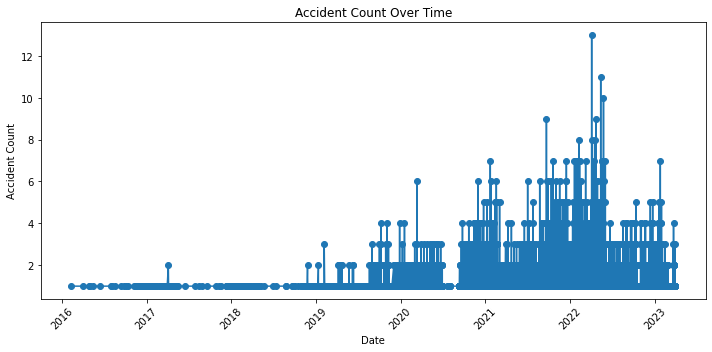

In [62]:
# Collect data from Spark to driver
rows = data.select("Date", "Accident_Count").orderBy("Date").collect()

# Convert to numpy arrays
dates = np.array([r["Date"] for r in rows])
accidents = np.array([r["Accident_Count"] for r in rows], dtype=float)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(dates, accidents, marker='o')
plt.title("Accident Count Over Time")
plt.xlabel("Date")
plt.ylabel("Accident Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [63]:
data = data.withColumn("day_of_week", dayofweek("Date"))
data = data.withColumn("month", month("Date"))
data = data.withColumn("is_weekend", when(col("day_of_week").isin([1,7]), 1).otherwise(0))
data = data.withColumn("quarter", quarter("Date"))

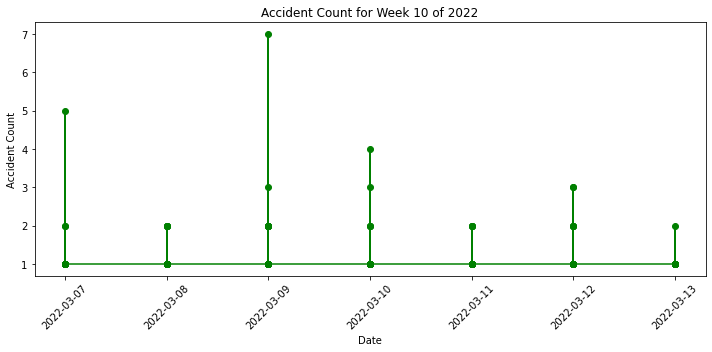

In [64]:
year_selected = 2022
week_selected = 10

# Filter data for that week
week_data = data.filter(
    (year("Date") == lit(year_selected)) &
    (weekofyear("Date") == lit(week_selected))
).orderBy("Date")

# Collect for plotting
rows = week_data.select("Date", "Accident_Count").collect()
dates = np.array([r["Date"] for r in rows])
counts = np.array([r["Accident_Count"] for r in rows], dtype=float)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(dates, counts, marker='o', color='green')
plt.title(f"Accident Count for Week {week_selected} of {year_selected}")
plt.xlabel("Date")
plt.ylabel("Accident Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [65]:
windowSpec = Window.partitionBy("City").orderBy("Date")

data = data.withColumn("lag_1", lag("Accident_Count", 1).over(windowSpec))
data = data.withColumn("lag_7", lag("Accident_Count", 7).over(windowSpec))
data = data.na.drop(subset=["lag_1", "lag_7"])

In [66]:
data.show(5)

+--------+----------+--------------+----+--------+----------+------+-----------+-----+----------+-------+-----+-----+
|    City|      Date|Accident_Count|Temp|Humidity|Visibility|Precip|day_of_week|month|is_weekend|quarter|lag_1|lag_7|
+--------+----------+--------------+----+--------+----------+------+-----------+-----+----------+-------+-----+-----+
|Abingdon|2021-11-23|             1|37.0|    30.0|      10.0|   0.0|          3|   11|         0|      4|    1|    1|
|Abingdon|2022-04-08|             1|58.0|    48.0|      10.0|   0.0|          6|    4|         0|      2|    1|    1|
|Abingdon|2022-12-13|             1|34.0|    52.0|      10.0|   0.0|          3|   12|         0|      4|    1|    1|
|Abington|2022-12-16|             1|43.0|    71.0|      10.0|   0.0|          6|   12|         0|      4|    1|    1|
|   Acton|2020-11-06|             1|75.0|    31.0|      10.0|   0.0|          6|   11|         0|      4|    1|    1|
+--------+----------+--------------+----+--------+------

In [67]:
train = data.filter(col("Date") < "2022-01-01")
test  = data.filter(col("Date") >= "2022-01-01")

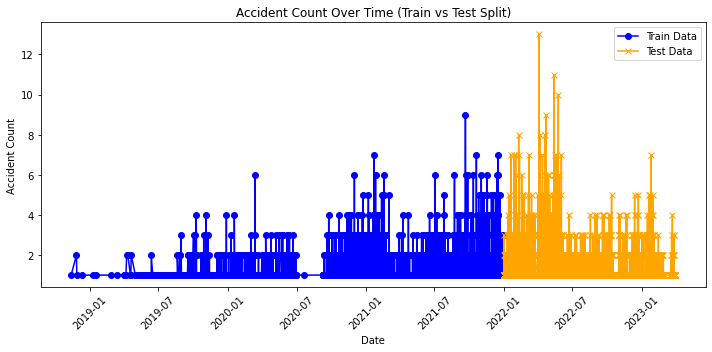

In [68]:
# Collect to driver
train_rows = train.select("Date", "Accident_Count").orderBy("Date").collect()
test_rows  = test.select("Date", "Accident_Count").orderBy("Date").collect()

# Convert to numpy arrays
train_dates = np.array([r["Date"] for r in train_rows])
train_counts = np.array([r["Accident_Count"] for r in train_rows], dtype=float)

test_dates = np.array([r["Date"] for r in test_rows])
test_counts = np.array([r["Accident_Count"] for r in test_rows], dtype=float)

# Plot both on same graph
plt.figure(figsize=(10, 5))
plt.plot(train_dates, train_counts, label='Train Data', color='blue', marker='o')
plt.plot(test_dates, test_counts, label='Test Data', color='orange', marker='x')

plt.title("Accident Count Over Time (Train vs Test Split)")
plt.xlabel("Date")
plt.ylabel("Accident Count")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [69]:
feature_cols = ["day_of_week", "month", "is_weekend", 
                "Temp", "Humidity", "Visibility", "Precip",
                "lag_1", "lag_7", "quarter"]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

train = assembler.transform(train)
test  = assembler.transform(test)

In [70]:
gbt = GBTRegressor(
    featuresCol="features",
    labelCol="Accident_Count",
    maxIter=200,
    maxDepth=8
)
model = gbt.fit(train)
predictions = model.transform(test)

25/11/09 21:10:30 WARN DAGScheduler: Broadcasting large task binary with size 1009.0 KiB
25/11/09 21:10:30 WARN DAGScheduler: Broadcasting large task binary with size 1011.0 KiB
25/11/09 21:10:31 WARN DAGScheduler: Broadcasting large task binary with size 1011.4 KiB
25/11/09 21:10:31 WARN DAGScheduler: Broadcasting large task binary with size 1012.0 KiB
25/11/09 21:10:31 WARN DAGScheduler: Broadcasting large task binary with size 1013.2 KiB
25/11/09 21:10:31 WARN DAGScheduler: Broadcasting large task binary with size 1015.2 KiB
25/11/09 21:10:31 WARN DAGScheduler: Broadcasting large task binary with size 1018.9 KiB
25/11/09 21:10:31 WARN DAGScheduler: Broadcasting large task binary with size 1025.1 KiB
25/11/09 21:10:31 WARN DAGScheduler: Broadcasting large task binary with size 1035.4 KiB
25/11/09 21:10:31 WARN DAGScheduler: Broadcasting large task binary with size 1036.2 KiB
25/11/09 21:10:31 WARN DAGScheduler: Broadcasting large task binary with size 1036.7 KiB
25/11/09 21:10:31 WAR

In [71]:
evaluator_rmse = RegressionEvaluator(
    labelCol="Accident_Count",
    predictionCol="prediction",
    metricName="rmse"
)
evaluator_mae = RegressionEvaluator(
    labelCol="Accident_Count",
    predictionCol="prediction",
    metricName="mae"
)

rmse = evaluator_rmse.evaluate(predictions)
mae = evaluator_mae.evaluate(predictions)

print(f"RMSE: {rmse:.2f}, MAE: {mae:.2f}")

RMSE: 0.61, MAE: 0.29


In [72]:
fi = model.featureImportances
features = feature_cols
pd.DataFrame({"Feature": features, "Importance": fi.toArray()}).sort_values(by="Importance", ascending=False)

,Feature,Importance
3,Temp,0.225048
4,Humidity,0.219511
0,day_of_week,0.158027
1,month,0.136169
7,lag_1,0.079027
8,lag_7,0.065025
5,Visibility,0.063904
6,Precip,0.034932
9,quarter,0.009428
2,is_weekend,0.008928


In [73]:
predictions.toPandas().to_numpy()

array([['Abingdon', datetime.date(2022, 4, 8), 1, ..., 1,
        DenseVector([6.0, 4.0, 0.0, 58.0, 48.0, 10.0, 0.0, 1.0, 1.0, 2.0]),
        0.9604472056820664],
       ['Abingdon', datetime.date(2022, 12, 13), 1, ..., 1,
        DenseVector([3.0, 12.0, 0.0, 34.0, 52.0, 10.0, 0.0, 1.0, 1.0, 4.0]),
        1.0028763076243365],
       ['Abington', datetime.date(2022, 12, 16), 1, ..., 1,
        DenseVector([6.0, 12.0, 0.0, 43.0, 71.0, 10.0, 0.0, 1.0, 1.0, 4.0]),
        1.1879329267415955],
       ...,
       ['Yuba City', datetime.date(2022, 11, 4), 1, ..., 1,
        DenseVector([6.0, 11.0, 0.0, 54.0, 53.0, 10.0, 0.0, 1.0, 1.0, 4.0]),
        1.0119268318451489],
       ['Yuba City', datetime.date(2023, 1, 29), 1, ..., 1,
        DenseVector([1.0, 1.0, 1.0, 46.0, 83.0, 10.0, 0.0, 1.0, 1.0, 1.0]),
        0.9878230548773106],
       ['Zebulon', datetime.date(2023, 1, 20), 1, ..., 1,
        DenseVector([6.0, 1.0, 0.0, 55.0, 38.0, 10.0, 0.0, 1.0, 1.0, 1.0]),
        1.0292662796399588]]

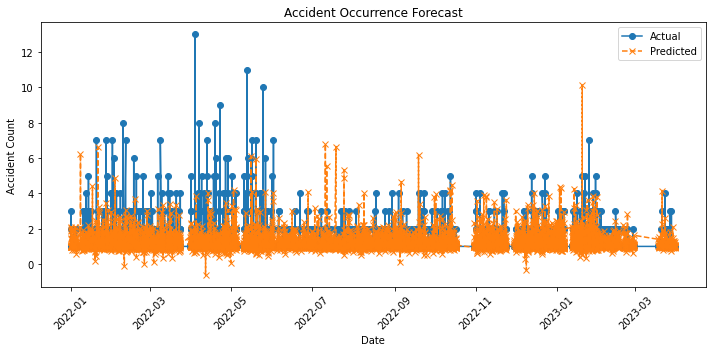

In [74]:
pdf = predictions.toPandas().to_numpy()

# Extract columns by position
dates = pdf[:, 1]                 # column 1 = Date
actual = pdf[:, 2].astype(float)  # column 2 = Accident_Count (convert to float)
predicted = pdf[:, -1].astype(float)  # last column = prediction

# Optional: sort by date to ensure the line plot is continuous
sort_idx = np.argsort(dates)
dates = np.array(dates)[sort_idx]
actual = actual[sort_idx]
predicted = predicted[sort_idx]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(dates, actual, label='Actual', marker='o')
plt.plot(dates, predicted, label='Predicted', linestyle='--', marker='x')
plt.xlabel('Date')
plt.ylabel('Accident Count')
plt.title('Accident Occurrence Forecast')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [75]:
spark.stop()